In [64]:
# Setup
# Cell 1: Setup
import data_loader
import importlib
importlib.reload(data_loader)


# print(f"Box size1: {BOX_SIZE}")

# Setup
from data_loader import *
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

print("BOX_SIZE2:", BOX_SIZE)


plt.rcParams.update({'font.size': 14})

Loading bubble data...
✓ Loaded 634277 observations
✓ Timesteps added: 0 to 3426
✓ Identified 300 disappearing bubbles
Applying periodic boundary corrections...
✓ Periodic boundary correction applied
✓ Derived quantities computed

DATA LOADING COMPLETE
Total observations:       634,277
Unique bubbles:           400
Timesteps:                0 to 3426
Disappearing bubbles:     300
Box size:                 22.36068
Initial avg area (A_0):   1.000000

Available variables:
  - df: Original dataframe
  - df_corrected: Corrected dataframe with actual_area column
  - disappearing_ids: Set of disappearing bubble IDs
  - bubbles_per_timestep: Number of bubbles at each timestep
  - avg_area_per_timestep: Average bubble area at each timestep
  - approx_avg_area: Approximate area from liquid fraction
  - A_0: Initial average bubble area
  - max_timestep: Maximum timestep
  - final_step: Final timestep
  - box_area: Total box area
  - BOX_SIZE, PERIODIC_THRESHOLD, LIQUID_FRACTION: Constants

BOX_S

In [ ]:
# Make globally positive coordinates for x and y
min_x = df_corrected["x"].min()
min_y = df_corrected["y"].min()


offset_x = 1.0 - min_x   # ensures min Sx ≈ 1
offset_y = 1.0 - min_y


df_corrected["Sx"] = df_corrected["x"] + offset_x
df_corrected["Sy"] = df_corrected["y"] + offset_y



# Function to get signed log-returns
def get_signed_logreturns_bubbles(dt):
    """Return pooled signed log-returns r_x, r_y for all bubbles at lag dt."""
    log_ret_x, log_ret_y = [], []

    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep").copy()
        Sx = g["Sx"].to_numpy()
        Sy = g["Sy"].to_numpy()

        if len(Sx) <= dt:
            continue

        r_x = np.log(Sx[dt:] / Sx[:-dt])
        r_y = np.log(Sy[dt:] / Sy[:-dt])

        log_ret_x.extend(r_x)
        log_ret_y.extend(r_y)

    
    # Plot x and y log-returns separately 
    plt.figure(figsize=(10,4))
    plt.plot(np.arange(len(log_ret_x)), log_ret_x, alpha=0.8, label='Log-Return X')
    plt.plot(np.arange(len(log_ret_y)), np.array(log_ret_y) - 0.3, alpha=0.8, label='Log-Return Y')
    plt.xlabel("Time")
    plt.ylabel("Log-Return")
    plt.title(f"Log-Returns")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    #plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures_Sample2/10_Figures/log_returns_xy_seperate_2.png", dpi=300, bbox_inches='tight')
    plt.show()

    log_ret = np.sqrt(np.array(log_ret_x)**2 + np.array(log_ret_y)**2)
    log_ret = log_ret - log_ret.mean()     # recentre (should be ~0 anyway)
    return log_ret 



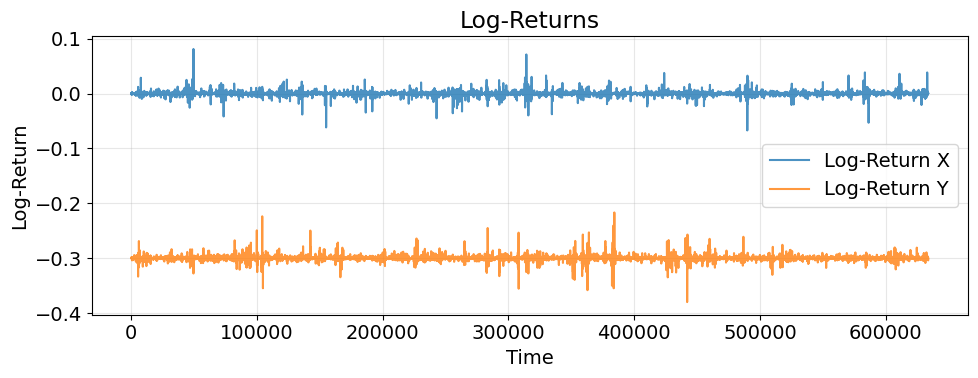

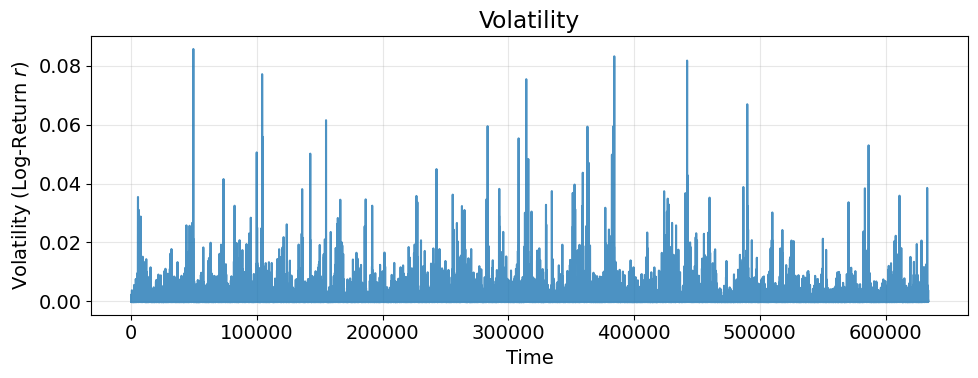

In [ ]:
# Get log-returns for dt=1    
log_ret = get_signed_logreturns_bubbles(dt=1)
time = np.arange(len(log_ret))

# Plot Log-Returns over Time
plt.figure(figsize=(10,4))
plt.plot(time, log_ret, alpha=0.8)
plt.xlabel("Time")
plt.ylabel("Volatility (Log-Return $r$)")
plt.title("Volatility")
plt.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures_Sample2/10_Figures/volatility_2.png", dpi=300, bbox_inches='tight')


